
Training Decision Tree...
              precision    recall  f1-score   support

           0       0.72      0.67      0.69       427
           1       0.39      0.48      0.43       238
           2       0.79      0.76      0.78       663

    accuracy                           0.68      1328
   macro avg       0.63      0.64      0.63      1328
weighted avg       0.70      0.68      0.69      1328


Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.81      0.76      0.79       427
           1       0.55      0.37      0.44       238
           2       0.80      0.93      0.86       663

    accuracy                           0.78      1328
   macro avg       0.72      0.69      0.70      1328
weighted avg       0.76      0.78      0.76      1328


Training Neural Network...
              precision    recall  f1-score   support

           0       0.74      0.71      0.72       427
           1       0.39      0.40      0.

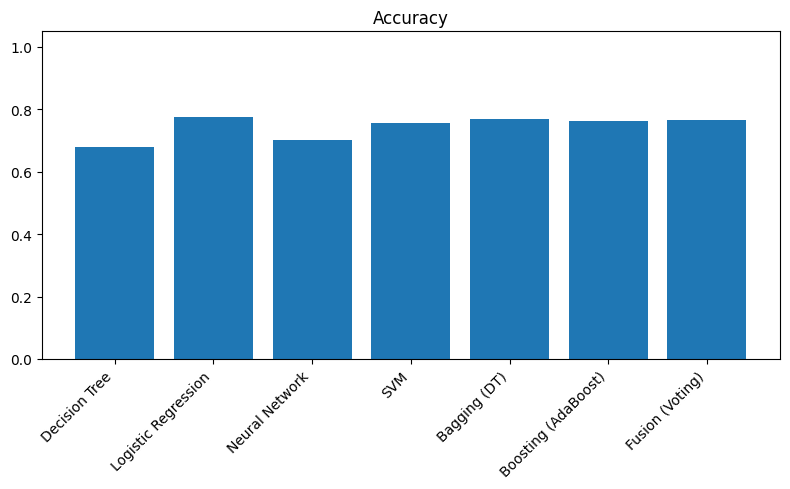

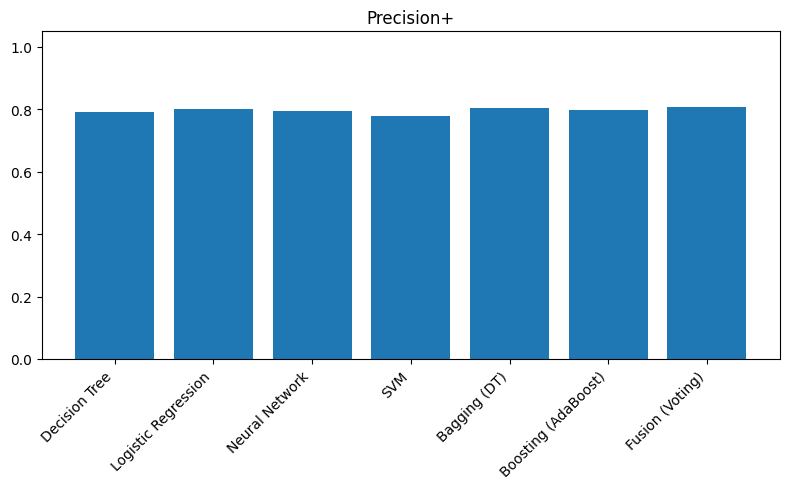

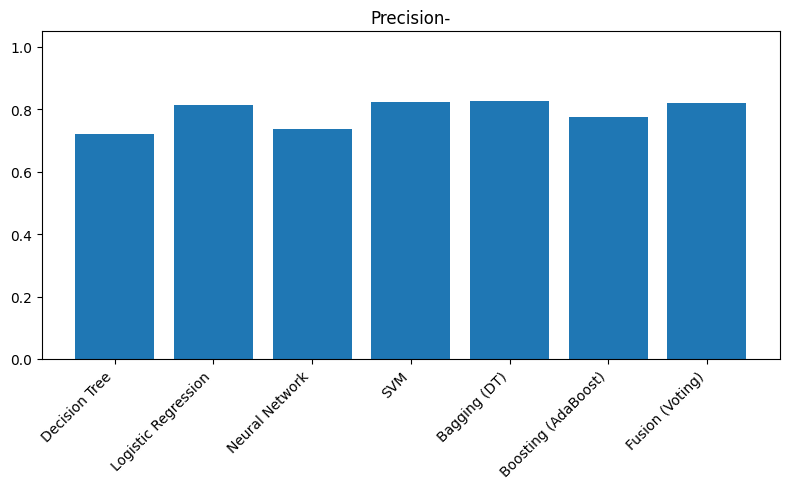

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.neural_network import MLPClassifier 
from sklearn.svm import SVC 
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, VotingClassifier 
from sklearn.metrics import accuracy_score, precision_score, classification_report 
from sklearn.base import clone 
 
# 1. Load & prepare dataset 
def load_data(path): 
    df = pd.read_csv('bida-1.csv') 
    target = df.columns[-1] 
    X, y = df.drop(columns=[target]), df[target] 
     
    # Encode target if categorical 
    if y.dtype == object or y.dtype.name == "category": 
        le = LabelEncoder() 
        y = le.fit_transform(y)  
    return X, y 
 
# 2. Build Preprocessor 
def build_preprocessor(X): 
    num_cols = X.select_dtypes(include=['number']).columns 
    cat_cols = X.select_dtypes(include=['object','category','bool']).columns 
     
    num_pipe = Pipeline([ 
        ('imputer', SimpleImputer(strategy='mean')), 
        ('scaler', StandardScaler()) 
    ]) 
    cat_pipe = Pipeline([ 
        ('imputer', SimpleImputer(strategy='most_frequent')), 
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
    ]) 
     
    return ColumnTransformer([ ('num', num_pipe, num_cols), 
        ('cat', cat_pipe, cat_cols) 
    ]) 
 
# 3. Define Models 
def get_models(pre): 
    clf_lr = LogisticRegression(max_iter=1000) 
    clf_dt = DecisionTreeClassifier(random_state=42) 
    clf_nn = MLPClassifier(max_iter=1000, random_state=42) 
     
    models = { 
        'Decision Tree': Pipeline([('pre', pre), ('clf', clf_dt)]), 
        'Logistic Regression': Pipeline([('pre', pre), ('clf', clf_lr)]), 
        'Neural Network': Pipeline([('pre', pre), ('clf', clf_nn)]), 
        'SVM': Pipeline([('pre', pre), ('clf', SVC(probability=True))]), 
        'Bagging (DT)': Pipeline([('pre', pre), 
            ('clf', BaggingClassifier(estimator=DecisionTreeClassifier(), 
                                      n_estimators=50, random_state=42))]), 
        'Boosting (AdaBoost)': Pipeline([('pre', pre), 
            ('clf', AdaBoostClassifier(n_estimators=50, random_state=42))]), 
        'Fusion (Voting)': Pipeline([('pre', pre), 
            ('vote', VotingClassifier( 
                estimators=[('lr', clf_lr), ('dt', clf_dt), ('nn', clf_nn)], 
                voting='soft'))]) 
    } 
    return models 
 
# 4. Training & Evaluation 
def evaluate(models, X_train, X_test, y_train, y_test): 
    results = [] 
    for name, model in models.items(): 
        print(f"\nTraining {name}...") 
        m = clone(model).fit(X_train, y_train) 
        y_pred = m.predict(X_test) 
         
        acc = accuracy_score(y_test, y_pred) 
        precisions = precision_score(y_test, y_pred, average=None, zero_division=0) 
        results.append({'Model': name, 
                        'Accuracy': acc, 
                        'Precision+': precisions[-1], 
                        'Precision-': precisions[0]}) 
         
        print(classification_report(y_test, y_pred, zero_division=0)) 
    return pd.DataFrame(results).set_index('Model') 
 
# 5. Plotting 
def plot_results(df): 
    for metric in df.columns: 
        plt.figure(figsize=(8,5)) 
        plt.bar(df.index, df[metric]) 
        plt.ylim(0,1.05) 
        plt.title(metric) 
        plt.xticks(rotation=45, ha='right') 
        plt.tight_layout() 
        plt.show() 
 
# Main Run 
X, y = load_data("data.csv") 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y) 
pre = build_preprocessor(X) 
models = get_models(pre) 
results_df = evaluate(models, X_train, X_test, y_train, y_test) 
 
print("\nFinal Results:\n", results_df) 
plot_results(results_df)